[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JasonCiemielewski/SVEF-Drug-Rescue/blob/main/notebooks/Midterm_Presentation.ipynb)

# Midterm Presentation

BIFX 546 Machine Learning for Bioinformatics - Spring 2026

Student: Jason Ciemielewski
Professor: Dr. Sarangan Ravichandran


## Introduction

There are many interventional drug clinical trials that reach phase 2/3 and do not succesfully complete.  These trials may not successfully complete for a variety of reasons. Trials may not successfully complete due to multiple issues such as toxicity, futility, business decisions, or administration issues.  Drug candidates in phase 2/3 trials that do not successfully complete their trial due to non toxicty reasons are particularly interesting candidates for drug repurposing.  These candidates have shown intial success in clearing toxicity hurdles and potentially represent less expensive drug development candidates.

This project aims to create the Safety Validated Efficacy Failed (SVEF) dataset to identify potential drug candidates for repurposing.  After candidates are identified, Interpretable cross-attention network (ICAN) will be used to identify potential new targets for these candidates.

## Set Up

In [1]:
import os
import sys

# 1. IDENTIFY ENVIRONMENT & ROOT
if os.path.exists('../src'):
    # Local IDE: Running from /notebooks folder
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
    print("Local Environment (Notebook Folder) detected. Skipping clone.")
elif os.path.exists('src'):
    # Local IDE: Running from Root
    PROJECT_ROOT = os.getcwd()
    print("Local Environment (Root Folder) detected. Skipping clone.")
else:
    # Google Colab: Fetch the repo folders
    print("Colab Environment detected. Fetching repository...")
    REPO_URL = "https://github.com/JasonCiemielewski/SVEF-Drug-Rescue.git"
    REPO_DIR = "SVEF-Drug-Rescue"
    !git clone {REPO_URL}
    %cd {REPO_DIR}
    PROJECT_ROOT = os.getcwd()

# 2. DEFINE PATHS & ADD TO SYS.PATH
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'demo') 
FIGURES_DIR = os.path.join(PROJECT_ROOT, 'reports', 'figures')
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print(f"System Ready. PROJECT_ROOT: {PROJECT_ROOT}")

Local Environment (Notebook Folder) detected. Skipping clone.
System Ready. PROJECT_ROOT: C:\Users\Ownwer\Documents\BIFX\BIFX546\Final_Project


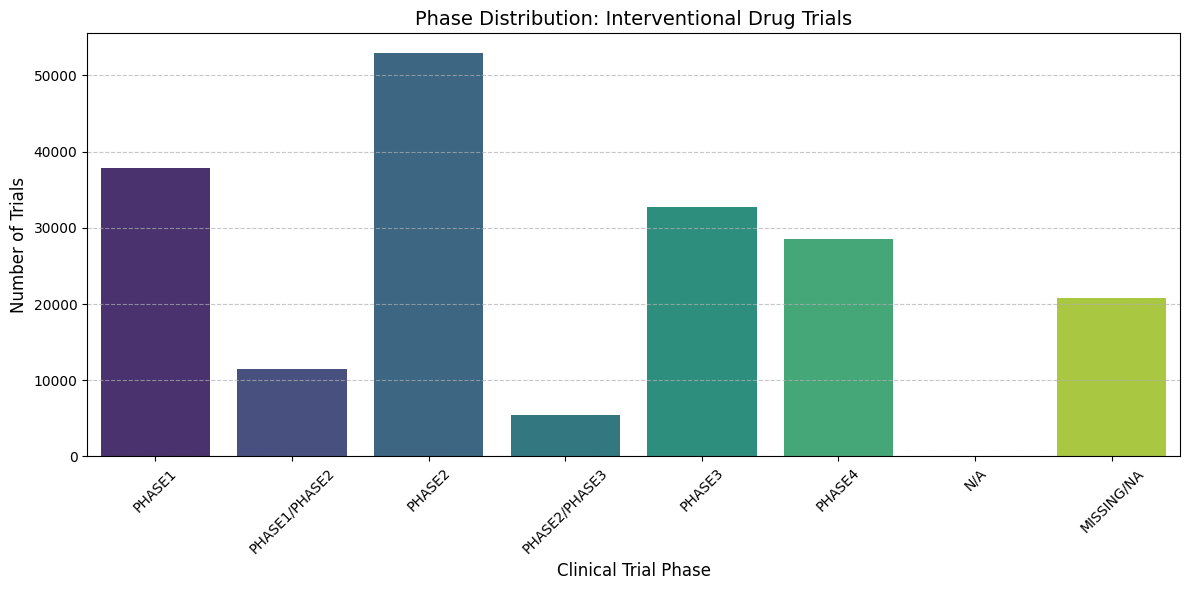

In [2]:
from IPython.display import Image, display
import os

# Use the verified path from your Master Setup
img_path = os.path.join(FIGURES_DIR, 'phase_dist_drug_interven.png')

if os.path.exists(img_path):
    display(Image(filename=img_path, width=800))
else:
    print(f"⚠️ Image not found at: {img_path}")
    print("Check if 'phase_dist_drug_interven.png' exists in your /reports/figures/ folder.")

The Phase Distribution: Interventional Drug Trials plot shows the number of clinical trials recorded in the AACT database 

In [3]:
%pip install highlight_text

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Ownwer\Documents\BIFX\BIFX546\Final_Project\.svef\Scripts\python.exe -m pip install --upgrade pip


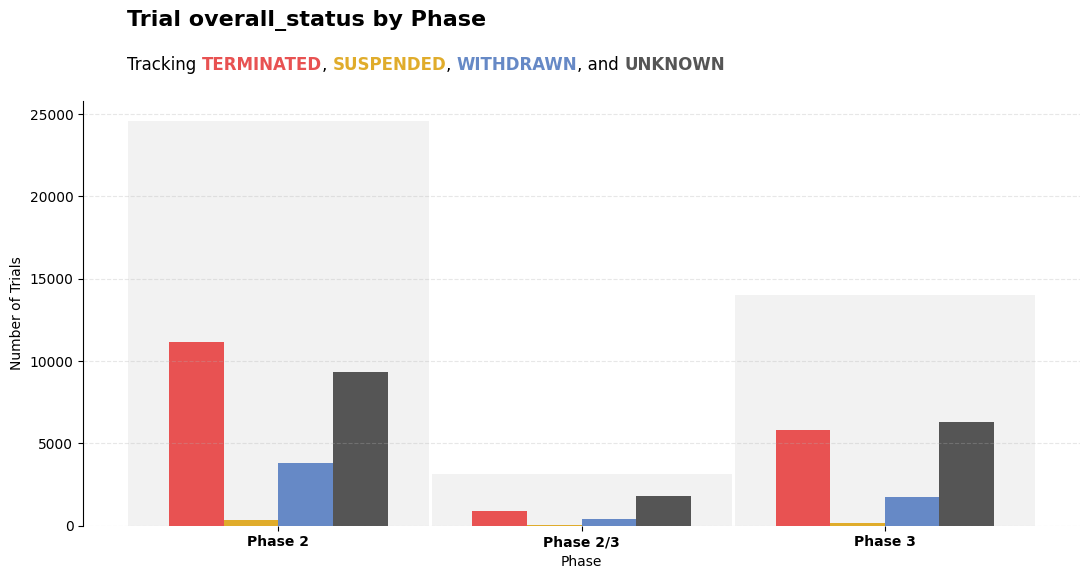

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from highlight_text import fig_text

# --- 1. DIRECT DATA LOAD ---
# Points directly to your production audit file
prod_audit_file = os.path.join(PROJECT_ROOT, 'data', 'interim', 'audit', 'svef_logic_audit.csv')
df = pd.read_csv(prod_audit_file)

# --- 2. FAST FILTER & PIVOT ---
phases = ['PHASE2', 'PHASE2/PHASE3', 'PHASE3']
statuses = ['TERMINATED', 'SUSPENDED', 'WITHDRAWN', 'UNKNOWN']

# Filter and Pivot in one go
pivot_df = (df[df['phase'].isin(phases)]
            .groupby(['phase', 'overall_status']).size()
            .unstack(fill_value=0)
            .reindex(index=phases, columns=statuses, fill_value=0))

# --- 3. PLOT EXECUTION ---
totals = pivot_df.sum(axis=1)
fig, ax = plt.subplots(figsize=(11, 6), dpi=100)
x = np.arange(len(pivot_df.index))
bar_width = 0.18
colors = ["#E85252", "#E0AC2B", "#6689C6", "#555555"] # Term, Susp, With, Unk

# Background Totals
ax.bar(x, totals, width=bar_width * 5.5, color="#F2F2F2", zorder=0)

# Bars
for i, status in enumerate(pivot_df.columns):
    ax.bar(x + (i - 1.5) * bar_width, pivot_df[status], 
           width=bar_width, color=colors[i], zorder=1)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(['Phase 2', 'Phase 2/3', 'Phase 3'], fontweight='bold')
ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_ylabel("Number of Trials")
ax.set_xlabel("Phase")

# Header & Legend
fig.text(x=0.12, y=0.96, s="Trial overall_status by Phase", size=16, weight="bold")
fig_text(x=0.12, y=0.91, 
         s="Tracking <TERMINATED>, <SUSPENDED>, <WITHDRAWN>, and <UNKNOWN>",
         highlight_textprops=[{"color": c, "weight": "bold"} for c in colors], size=12)

# --- 4. DIRECT SAVE ---
plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.savefig(os.path.join(FIGURES_DIR, "overall_status_landscape.png"), bbox_inches="tight")
plt.show()

### Demonstration Data

Due to the size of the numerous datasets involved, a demonstration set of data has been prepared to illustrate how the SVEF dataset was created.

#### Load Demonstration Data

In [5]:
import pandas as pd
import numpy as np
import os

# 1. Define the loading function with the Production Guardrail
def load_raw_demo(name):
    """
    Ingests demo data using the same Type-Hardening logic 
    as the production 'load_filtered' function.
    """
    path = os.path.join(DATA_DIR, f"{name}_micro.csv")
    df = pd.read_csv(path)
    
    # THE PRODUCTION MIRROR: Force IDs to strings immediately
    # This prevents the 'str vs int64' ValueError in Section 5
    hardened_cols = ['nct_id', 'id', 'design_group_id', 'intervention_id', 'pmid']
    for col in hardened_cols:
        if col in df.columns:
            # fillna('') ensures NaNs don't force the column back to float64/int64
            df[col] = df[col].fillna('').astype(str)
            
    return df

# 2. Re-load all 9 tables to sync them with the Production Pipeline
studies_raw = load_raw_demo('studies')
interventions_raw = load_raw_demo('interventions')
design_groups_raw = load_raw_demo('design_groups')
dg_inter_raw = load_raw_demo('design_group_interventions')
id_info_raw = load_raw_demo('id_information')
refs_raw = load_raw_demo('study_references')
sponsors_raw = load_raw_demo('sponsors')
calc_vals_raw = load_raw_demo('calculated_values')
conditions_raw = load_raw_demo('browse_conditions')

print("✅ Data Ingestion Complete: All tables synchronized with Production string-types.")

✅ Data Ingestion Complete: All tables synchronized with Production string-types.


### Demonstration of Pipeline

#### Initial Filtering and Joining

Perform initial structural filtering for Phase 2, 3, and 2/3 trials, are drug interventions, and have outcome statuses of Terminated, Suspended, Withdraw, and Unknown.  Exclude some biologics that may be categorized as drug (and not biologic) interventions.

In [6]:
from src.data.make_dataset import filter_structural

structural_pool, _ = filter_structural(studies_raw, interventions_raw)
print(f"Rows passing structural gate: {len(structural_pool)}")
display(structural_pool[['nct_id', 'name', 'phase', 'overall_status', 'why_stopped']].head(15))

Rows passing structural gate: 67


,nct_id,name,phase,overall_status,why_stopped
0,NCT00630994,Dacogen,PHASE2,TERMINATED,Stopped due to slow accrual
1,NCT06839872,Pirtobrutinib,PHASE2,WITHDRAWN,AstraZeneca has made the decision to cancel th...
2,NCT06839872,Acalabrutinib,PHASE2,WITHDRAWN,AstraZeneca has made the decision to cancel th...
3,NCT01829464,Placebo,PHASE3,TERMINATED,Due to potential concerns about liver safety (...
4,NCT01829464,TAK-875,PHASE3,TERMINATED,Due to potential concerns about liver safety (...
5,NCT01829464,TAK-875,PHASE3,TERMINATED,Due to potential concerns about liver safety (...
7,NCT00261352,Tesaglitazar,PHASE3,TERMINATED,The development program has been terminated
8,NCT00261352,Metformin,PHASE3,TERMINATED,The development program has been terminated
9,NCT00261352,Fenofibrate,PHASE3,TERMINATED,The development program has been terminated
10,NCT00401310,Comparator: Placebo,PHASE2,TERMINATED,Termination date was 20-Oct-2008. Subjects wer...


In [7]:
structural_pool.columns

Index(['nct_id', 'study_type', 'phase', 'overall_status', 'why_stopped', 'id',
       'intervention_type', 'name', 'description'],
      dtype='str')

In [8]:
studies_raw.columns

Index(['nct_id', 'nlm_download_date_description', 'study_first_submitted_date',
       'results_first_submitted_date', 'disposition_first_submitted_date',
       'last_update_submitted_date', 'study_first_submitted_qc_date',
       'study_first_posted_date', 'study_first_posted_date_type',
       'results_first_submitted_qc_date', 'results_first_posted_date',
       'results_first_posted_date_type', 'disposition_first_submitted_qc_date',
       'disposition_first_posted_date', 'disposition_first_posted_date_type',
       'last_update_submitted_qc_date', 'last_update_posted_date',
       'last_update_posted_date_type', 'start_month_year', 'start_date_type',
       'start_date', 'verification_month_year', 'verification_date',
       'completion_month_year', 'completion_date_type', 'completion_date',
       'primary_completion_month_year', 'primary_completion_date_type',
       'primary_completion_date', 'target_duration', 'study_type', 'acronym',
       'baseline_population', 'brief_titl

In [9]:
interventions_raw.columns

Index(['id', 'nct_id', 'intervention_type', 'name', 'description'], dtype='str')

#### Natural Language Processinig on why_stopped

Keyword searches are performed using Regular Expression (Regex) for three categories:
- Efficacy (futility', 'efficacy', 'lack of effect', 'benefit', 'endpoint', 'superiority', 'insufficient signal)
- Safety ('toxic', 'adverse event', 'side effect', 'harm', 'risk', 'death', 'mortality', 'aes', 'safety)
- Logistical (recruitment', 'accrual', 'enrollment', 'funding', 'covid', 'personnel', 'feasibility', 'operational)

Negation phrases are included to help reduce miscategorization (e.g. no safety concerns', 'no safety issues', 'not due to safety')

"audit_status" are assigned.  
- TERMINATED_SAFETY_CONCERN
- TERMINATED_EFFICACY_FAILURE
- TERMINATED_CLEAN_EXIT
- SUSPENDED_SAFETY_CONCERN
- SUSPENDED_EFFICACY_FAILURE
- SUSPENDED_CLEAN_EXIT
- WITHDRAWN_STRATEGIC
- WITHDRAWN_LOGISTICAL
- WITHDRAWN_OTHER

In [10]:
from src.data.make_dataset import apply_unified_svef_logic

candidates, audit_trace = apply_unified_svef_logic(structural_pool)
display(audit_trace[['nct_id', 'audit_status', 'why_stopped']].head(10))

,nct_id,audit_status,why_stopped
0,NCT00630994,TERMINATED_CLEAN_EXIT,Stopped due to slow accrual
1,NCT06839872,WITHDRAWN_OTHER,AstraZeneca has made the decision to cancel th...
2,NCT06839872,WITHDRAWN_OTHER,AstraZeneca has made the decision to cancel th...
3,NCT01829464,TERMINATED_SAFETY_CONCERN,Due to potential concerns about liver safety (...
4,NCT01829464,TERMINATED_SAFETY_CONCERN,Due to potential concerns about liver safety (...
5,NCT01829464,TERMINATED_SAFETY_CONCERN,Due to potential concerns about liver safety (...
7,NCT00261352,TERMINATED_CLEAN_EXIT,The development program has been terminated
8,NCT00261352,TERMINATED_CLEAN_EXIT,The development program has been terminated
9,NCT00261352,TERMINATED_CLEAN_EXIT,The development program has been terminated
10,NCT00401310,TERMINATED_CLEAN_EXIT,Termination date was 20-Oct-2008. Subjects wer...


In [11]:
audit_trace.columns

Index(['nct_id', 'study_type', 'phase', 'overall_status', 'why_stopped', 'id',
       'intervention_type', 'name', 'description', 'why_stopped_clean',
       'has_eff', 'has_safe', 'has_log', 'is_negated', 'eff_flag', 'safe_flag',
       'audit_status', 'inclusion_trigger', 'exclusion_trigger'],
      dtype='str')

In [12]:
audit_trace.head(10)

,nct_id,study_type,phase,overall_status,why_stopped,id,intervention_type,name,description,why_stopped_clean,has_eff,has_safe,has_log,is_negated,eff_flag,safe_flag,audit_status,inclusion_trigger,exclusion_trigger
0,NCT00630994,INTERVENTIONAL,PHASE2,TERMINATED,Stopped due to slow accrual,299875046,DRUG,Dacogen,NaN,stopped due to slow accrual,False,False,True,False,False,False,TERMINATED_CLEAN_EXIT,NaN,NaN
1,NCT06839872,INTERVENTIONAL,PHASE2,WITHDRAWN,AstraZeneca has made the decision to cancel th...,299875176,DRUG,Pirtobrutinib,Patients will receive pirtobrutinib orally wit...,astrazeneca has made the decision to cancel th...,False,False,False,False,False,False,WITHDRAWN_OTHER,NaN,NaN
2,NCT06839872,INTERVENTIONAL,PHASE2,WITHDRAWN,AstraZeneca has made the decision to cancel th...,299875177,DRUG,Acalabrutinib,Patients will receive acalabrutinib orally wit...,astrazeneca has made the decision to cancel th...,False,False,False,False,False,False,WITHDRAWN_OTHER,NaN,NaN
3,NCT01829464,INTERVENTIONAL,PHASE3,TERMINATED,Due to potential concerns about liver safety (...,299909305,DRUG,Placebo,TAK-875 placebo-matching tablets,due to potential concerns about liver safety (...,False,True,False,False,False,True,TERMINATED_SAFETY_CONCERN,NaN,safety
4,NCT01829464,INTERVENTIONAL,PHASE3,TERMINATED,Due to potential concerns about liver safety (...,299909306,DRUG,TAK-875,TAK-875 tablets,due to potential concerns about liver safety (...,False,True,False,False,False,True,TERMINATED_SAFETY_CONCERN,NaN,safety
5,NCT01829464,INTERVENTIONAL,PHASE3,TERMINATED,Due to potential concerns about liver safety (...,299909307,DRUG,TAK-875,TAK-875 tablets,due to potential concerns about liver safety (...,False,True,False,False,False,True,TERMINATED_SAFETY_CONCERN,NaN,safety
7,NCT00261352,INTERVENTIONAL,PHASE3,TERMINATED,The development program has been terminated,299875297,DRUG,Tesaglitazar,NaN,the development program has been terminated,False,False,False,False,False,False,TERMINATED_CLEAN_EXIT,NaN,NaN
8,NCT00261352,INTERVENTIONAL,PHASE3,TERMINATED,The development program has been terminated,299875298,DRUG,Metformin,NaN,the development program has been terminated,False,False,False,False,False,False,TERMINATED_CLEAN_EXIT,NaN,NaN
9,NCT00261352,INTERVENTIONAL,PHASE3,TERMINATED,The development program has been terminated,299875299,DRUG,Fenofibrate,NaN,the development program has been terminated,False,False,False,False,False,False,TERMINATED_CLEAN_EXIT,NaN,NaN
10,NCT00401310,INTERVENTIONAL,PHASE2,TERMINATED,Termination date was 20-Oct-2008. Subjects wer...,299875310,DRUG,Comparator: Placebo,Placebo IV infusions 1hr/daily over 7 days.,termination date was 20-oct-2008. subjects wer...,False,False,False,False,False,False,TERMINATED_CLEAN_EXIT,NaN,NaN


In [13]:
%pip install highlight_text

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Ownwer\Documents\BIFX\BIFX546\Final_Project\.svef\Scripts\python.exe -m pip install --upgrade pip


✅ Plot successfully saved to: C:\Users\Ownwer\Documents\BIFX\BIFX546\Final_Project\reports\figures\demo_overall_status_landscape.png


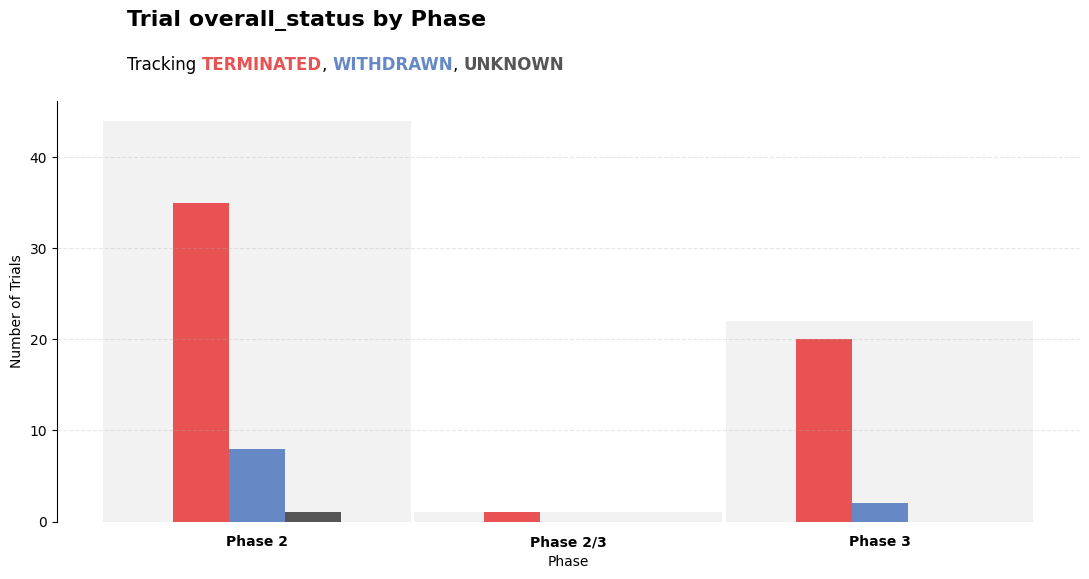

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from highlight_text import fig_text

# 1. Filter for specific phases
phases_to_plot = ['PHASE2', 'PHASE2/PHASE3', 'PHASE3']
plot_data = audit_trace[audit_trace['phase'].isin(phases_to_plot)].copy()

# 2. Pivot the data: Rows = Phase, Columns = Overall Status
pivot_df = plot_data.groupby(['phase', 'overall_status']).size().unstack(fill_value=0)

# Ensure phases are in order and only columns that exist are used
pivot_df = pivot_df.reindex(phases_to_plot)
status_order = ['TERMINATED', 'SUSPENDED', 'WITHDRAWN', 'UNKNOWN']
existing_statuses = [c for c in status_order if c in pivot_df.columns]
pivot_df = pivot_df[existing_statuses]

# 3. Setup Plotting Variables
totals = pivot_df.sum(axis=1)
fig, ax = plt.subplots(figsize=(11, 6), dpi=100)
bar_width = 0.18 
x = np.arange(len(pivot_df.index))

# Define the Master Color Map
full_color_map = {
    'TERMINATED': "#E85252", 
    'SUSPENDED': "#E0AC2B", 
    'WITHDRAWN': "#6689C6", 
    'UNKNOWN': "#555555"
}
# Extract only colors for statuses present in this specific data slice
active_colors = [full_color_map[col] for col in pivot_df.columns]

# 4. Draw Background Totals (The Context Rectangles)
ax.bar(x, totals, width=bar_width * 5.5, color="#F2F2F2", zorder=0)

# 5. Draw the Grouped Bars
for i, status in enumerate(pivot_df.columns):
    ax.bar(
        x + (i - (len(pivot_df.columns)-1)/2) * bar_width, 
        pivot_df[status],
        width=bar_width,
        zorder=1,
        color=active_colors[i],
        label=status
    )

# 6. Styling & Formatting
ax.set_xticks(x)
ax.set_xticklabels(['Phase 2', 'Phase 2/3', 'Phase 3'], fontsize=10, fontweight='bold')
ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.tick_params(axis="x", size=0, pad=10)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_ylabel("Number of Trials")
ax.set_xlabel("Phase")

# 7. Header and Legend 
fig.text(x=0.12, y=0.96, s="Trial overall_status by Phase", size=16, weight="bold")

# Dynamically wrap each status in brackets for the color-matching
status_labels = [f"<{col}>" for col in pivot_df.columns]
legend_string = "Tracking " + ", ".join(status_labels)

fig_text(
    x=0.12,
    y=0.91,
    s=legend_string,
    highlight_textprops=[{"color": c, "weight": "bold"} for c in active_colors],
    size=12
)

plt.tight_layout(rect=[0, 0.03, 1, 0.9])
save_path = os.path.join(FIGURES_DIR, "demo_overall_status_landscape.png")
plt.savefig(save_path, bbox_inches="tight")

print(f"✅ Plot successfully saved to: {save_path}")
plt.show()

#### Mapping Candidate Relationship within Trial

nct_id, design_group_id, and intervention_id are mapped together.  group_type is collapsed into single entry using "|" to help 

In [15]:
from src.features.enrich_dataset import map_intervention_roles

# Production Logic: Mapping intervention roles via design groups
total_evidence_df = map_intervention_roles(audit_trace, design_groups_raw, dg_inter_raw)

print(f"Total rows in Evidence DataFrame: {len(total_evidence_df)}")
display(total_evidence_df[['nct_id', 'name', 'group_type', 'audit_status', 'intervention_id']].head(10))

Mapping intervention roles via design groups...
Total rows in Evidence DataFrame: 67


,nct_id,name,group_type,audit_status,intervention_id
0,NCT00630994,Dacogen,Other,TERMINATED_CLEAN_EXIT,NaN
1,NCT06839872,Pirtobrutinib,EXPERIMENTAL,WITHDRAWN_OTHER,299875176
2,NCT06839872,Acalabrutinib,EXPERIMENTAL,WITHDRAWN_OTHER,299875177
3,NCT01829464,Placebo,PLACEBO_COMPARATOR,TERMINATED_SAFETY_CONCERN,299909305
4,NCT01829464,TAK-875,EXPERIMENTAL,TERMINATED_SAFETY_CONCERN,299909306
5,NCT01829464,TAK-875,EXPERIMENTAL,TERMINATED_SAFETY_CONCERN,299909307
6,NCT00261352,Tesaglitazar,Other,TERMINATED_CLEAN_EXIT,NaN
7,NCT00261352,Metformin,Other,TERMINATED_CLEAN_EXIT,NaN
8,NCT00261352,Fenofibrate,Other,TERMINATED_CLEAN_EXIT,NaN
9,NCT00401310,Comparator: Placebo,PLACEBO_COMPARATOR,TERMINATED_CLEAN_EXIT,299875310


In [16]:
total_evidence_df.columns

Index(['nct_id', 'study_type', 'phase', 'overall_status', 'why_stopped', 'id',
       'intervention_type', 'name', 'description', 'why_stopped_clean',
       'has_eff', 'has_safe', 'has_log', 'is_negated', 'eff_flag', 'safe_flag',
       'audit_status', 'inclusion_trigger', 'exclusion_trigger',
       'intervention_id', 'group_type'],
      dtype='str')

In [17]:
total_evidence_df['intervention_id'].value_counts()

intervention_id
299875176    1
299875177    1
299909305    1
299909306    1
299909307    1
299875310    1
299875311    1
299875338    1
299875357    1
299875358    1
299875412    1
299875413    1
299875529    1
299875530    1
299289865    1
299875744    1
299875757    1
299875758    1
299875932    1
299875959    1
299875960    1
299876019    1
299876020    1
299876021    1
299876047    1
299876068    1
299876069    1
299876265    1
299876266    1
299876267    1
299876268    1
299876293    1
299876309    1
299876401    1
299876402    1
299876420    1
299876488    1
299876489    1
299876534    1
299876535    1
299876562    1
299874362    1
299874363    1
299876713    1
299876736    1
299876772    1
299876820    1
299877118    1
299877275    1
299877331    1
299877719    1
299291598    1
299291599    1
299291600    1
299487836    1
299487838    1
299291842    1
299291843    1
299489342    1
Name: count, dtype: int64

In [18]:
total_evidence_df['nct_id'].value_counts()

nct_id
NCT00544778    4
NCT01829464    3
NCT00261352    3
NCT04465916    3
NCT00313482    3
NCT00313014    3
NCT06839872    2
NCT00401310    2
NCT00320801    2
NCT00323362    2
NCT04535518    2
NCT06011577    2
NCT00470249    2
NCT01408056    2
NCT00517868    2
NCT00483119    2
NCT04190056    2
NCT02378870    2
NCT00406419    2
NCT03532542    2
NCT00630994    1
NCT04909879    1
NCT01419795    1
NCT05798611    1
NCT04895046    1
NCT00265863    1
NCT05005468    1
NCT03112720    1
NCT05349760    1
NCT01119118    1
NCT05657457    1
NCT01340794    1
NCT00511329    1
NCT05005000    1
NCT03147040    1
NCT00210366    1
NCT01886105    1
NCT04784455    1
NCT00003452    1
NCT06536465    1
Name: count, dtype: int64

In [19]:
design_groups_raw.columns

Index(['design_group_id', 'nct_id', 'group_type', 'title', 'description'], dtype='str')

In [20]:
design_groups_raw['group_type'].value_counts()

group_type
EXPERIMENTAL          88
ACTIVE_COMPARATOR     18
PLACEBO_COMPARATOR    11
Other                  5
NO_INTERVENTION        4
OTHER                  4
Name: count, dtype: int64

In [21]:
dg_inter_raw.columns

Index(['id', 'nct_id', 'design_group_id', 'intervention_id'], dtype='str')

#### Feature Enrichment - Enrollment, Clinical Metadata 

Enrollment data (for whole trial), start dates, end dates, trial duration days, log transformation of enrollment, normalization of log enrollment, and normalization of trial duration days is added.  "safety score" concept is introduction by comparing normalized trial duration days and normalized log enrollment.

Additional clinical metadata is merged and further regex based filtering for biologics is performed.

$$ \text{Safety\_Score} = \frac{\text{Norm}(\ln(1 + E)) + \text{Norm}(D)}{2} $$

**Where:**
* $E$ is the total trial **Enrollment**.
* $D$ is the **Trial Duration** in days ($\text{Primary Completion Date} - \text{Start Date}$).
* $\text{Norm}(x) = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$ (Min-Max Normalization).

In [22]:
from src.features.enrich_dataset import feature_engineering_advanced, merge_clinical_metadata

enriched_df = merge_clinical_metadata(total_evidence_df, studies_raw, calc_vals_raw, sponsors_raw, conditions_raw)
stats_df = feature_engineering_advanced(enriched_df)

display(stats_df[['nct_id', 'enrollment', 'log_enrollment', 'Safety_Score']].head())

Merging enriched clinical metadata...
Executing Advanced Feature Engineering...


,nct_id,enrollment,log_enrollment,Safety_Score
0,NCT00630994,4.0,1.609438,0.167439
1,NCT06839872,0.0,0.000000,0.135541
2,NCT06839872,0.0,0.000000,0.135541
3,NCT01829464,90.0,4.510860,0.342875
4,NCT01829464,90.0,4.510860,0.342875


In [23]:
enriched_df.columns

Index(['nct_id', 'study_type_x', 'phase_x', 'overall_status_x',
       'why_stopped_x', 'id_x', 'intervention_type', 'name', 'description',
       'why_stopped_clean',
       ...
       'number_of_primary_outcomes_to_measure',
       'number_of_secondary_outcomes_to_measure',
       'number_of_other_outcomes_to_measure', 'agency_class', 'mesh_term',
       'trial_duration_days', 'log_enrollment', 'norm_enrollment',
       'norm_duration', 'Safety_Score'],
      dtype='str', length=116)

#### Feature Enrichment - Publications

Publications relating to trial and drug candidate are querried at pubmed.  DOI is extracted from study_references.txt.  Attempts to categorize references as either results based (results from trial) or background based (anything not results based, i.e. pre-clinical studies, reviews, related research).  Attempts to create a score for evidence confidence.

$$ \text{Evidence\_Confidence} = (N_{\text{results}} \times 1.0) + (N_{\text{background}} \times 0.2) + \begin{cases} 0.5 & \text{if } N_{\text{results}} > 0 \\ 0 & \text{otherwise} \end{cases} $$

In [24]:
from src.features.enrich_dataset import process_publications

evidence_df = process_publications(refs_raw)
display(evidence_df.head(10))

,nct_id,publication_count,Evidence_Confidence,results_pmid_list,background_pmid_list,doi_list
0,NCT00313014,1,1.5,21807566,,10.1016/j.jpain.2011.06.003.
1,NCT00406419,2,0.4,,24498318|21905001,10.1371/journal.pone.0087379.|10.1002/art.33317.
2,NCT00483119,4,0.8,,19075146|18490602|18423257|18490594,10.1001/archdermatol.2008.503.|10.1001/archder...
3,NCT00511329,5,1.0,,11739431|11782884|11549686|16117811|17018651,10.1210/jcem.86.12.8083.|10.1053/meta.2002.289...
4,NCT00517868,1,0.2,,22082303,10.1111/j.1743-6109.2011.02542.x.
5,NCT01119118,1,0.2,,25128349,10.1016/j.clgc.2014.07.001.
6,NCT01169259,38,7.6,,26767629|25864623|21986389|30415629|30415637|3...,10.1016/j.cct.2015.12.022.|10.1016/j.jsbmb.201...
7,NCT01395342,1,0.2,,23997960,10.1155/2013/857047.
8,NCT01408056,5,1.0,,20479314|19143471|19706583|21158749|18035154,10.1001/archdermatol.2010.67.|10.1371/journal....
9,NCT01829464,1,0.2,,30880443,10.1177/1740774519836766.


#### Feature Enrichment - PubChem

##### Drug Name Cleaning

Drug names are cleaned prior to querrying PubChem with a worker function during the enrich_with_pubchem_architect()

In [25]:
# Worker function that cleans drug names for querry
from src.features.enrich_dataset import clean_drug_name

test_cases = ["Dasatinib 100 MG [Sprycel]", "Timolol 0.5% Gel", "Amlodipine Besylate"]
for drug in test_cases:
    print(f"Raw: {drug:<30} -> Cleaned: {clean_drug_name(drug)}")

Raw: Dasatinib 100 MG [Sprycel]     -> Cleaned: Dasatinib
Raw: Timolol 0.5% Gel               -> Cleaned: Timolol
Raw: Amlodipine Besylate            -> Cleaned: Amlodipine


##### Failure Categorization

Failures to retrieve smiles data from PubChem are categorized as PLACEBO_EQUIVALENT, LOGISTICAL_GENERIC, POSSIBLE_INTERNAL_PROPRIETARY

In [26]:
from src.features.enrich_dataset import classify_failure

print(f"Categorizing 'AZD-1234': {classify_failure('AZD-1234')}")
print(f"Categorizing 'Placebo': {classify_failure('Placebo')}")

Categorizing 'AZD-1234': POSSIBLE_INTERNAL_PROPRIETARY
Categorizing 'Placebo': PLACEBO_EQUIVALENT


##### Enriching with PubChem in Action

In [27]:
from src.features.enrich_dataset import enrich_with_pubchem_architect

# We define a local demo cache to avoid overwriting production cache
demo_cache_path = os.path.join(DATA_DIR, 'smiles_cache_demo.csv')

print("Starting Bio-Architectural Chemical Enrichment...")
# This calls the production API-tier logic
final_enriched_demo = enrich_with_pubchem_architect(stats_df, cache_path=demo_cache_path)

# Display the results of the recovery
print("\n--- Micro-Dataset Recovery Results ---")
display(final_enriched_demo[['name', 'pubchem_cid', 'smiles', 'matched_by', 'failure_reason']].head(15))

# Validation: Count how many are now 'DTI-Ready' (have SMILES)
dti_ready_count = final_enriched_demo['is_dti_ready'].sum()
print(f"\nTotal Assets ready for Drug-Target Interaction (DTI) modeling: {dti_ready_count} / {len(final_enriched_demo)}")

Starting Bio-Architectural Chemical Enrichment...
Loading architectural cache from C:\Users\Ownwer\Documents\BIFX\BIFX546\Final_Project\data\demo\smiles_cache_demo.csv...
Bioinformatics Recovery Phase: 64 unique drug names to process.

--- SMILES Recovery Summary ---
Matched by Name: 37
Matched by CAS: 0
Matched by Synonym: 0
Matched by Failed: 27

--- Micro-Dataset Recovery Results ---


,name,pubchem_cid,smiles,matched_by,failure_reason
0,Dacogen,451668.0,C1[C@@H]([C@H](O[C@H]1N2C=NC(=NC2=O)N)CO)O,Name,NaN
1,Pirtobrutinib,129269915.0,C[C@@H](C(F)(F)F)N1C(=C(C(=N1)C2=CC=C(C=C2)CNC...,Name,NaN
2,Acalabrutinib,71226662.0,CC#CC(=O)N1CCC[C@H]1C2=NC(=C3N2C=CN=C3N)C4=CC=...,Name,NaN
3,Placebo,NaN,NaN,Failed,PLACEBO_EQUIVALENT
4,TAK-875,24857286.0,CC1=CC(=CC(=C1C2=CC=CC(=C2)COC3=CC4=C(C=C3)[C@...,Name,NaN
5,TAK-875,24857286.0,CC1=CC(=CC(=C1C2=CC=CC(=C2)COC3=CC4=C(C=C3)[C@...,Name,NaN
6,Tesaglitazar,208901.0,CCO[C@@H](CC1=CC=C(C=C1)OCCC2=CC=C(C=C2)OS(=O)...,Name,NaN
7,Metformin,4091.0,CN(C)C(=N)N=C(N)N,Name,NaN
8,Fenofibrate,3339.0,CC(C)OC(=O)C(C)(C)OC1=CC=C(C=C1)C(=O)C2=CC=C(C...,Name,NaN
9,Comparator: Placebo,NaN,NaN,Failed,PLACEBO_EQUIVALENT



Total Assets ready for Drug-Target Interaction (DTI) modeling: 39 / 67


## SVEF_Enriched

### Visualizations of SVEF_Enriched

#### Presence of SMILES data for SVEF candidates

✅ Comparison plot saved to: C:\Users\Ownwer\Documents\BIFX\BIFX546\Final_Project\reports\figures\smiles_availability_comparison.png
📊 Results: 9644 candidates with SMILES, 12709 missing.


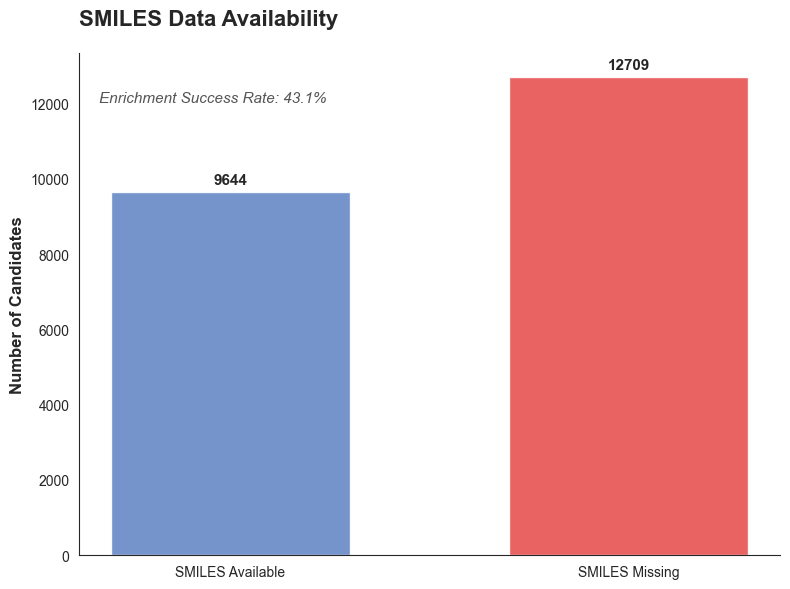

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load the Enriched Dataset
file_path = os.path.join(PROCESSED_DIR, 'SVEF_Enriched_Final.csv')

try:
    df = pd.read_csv(file_path)
    
    # 2. Check for SMILES data
    # We check for 'smiles' or 'canonical_smiles' columns common in PubChem enrichment
    smiles_col = 'smiles' if 'smiles' in df.columns else 'canonical_smiles'
    
    if smiles_col not in df.columns:
        print(f"⚠️ Warning: No SMILES column found. Available columns: {df.columns.tolist()}")
    else:
        # Calculate counts
        has_smiles = df[smiles_col].notna().sum()
        no_smiles = df[smiles_col].isna().sum()
        
        # 3. Create Visualization Data
        plot_df = pd.DataFrame({
            'Category': ['SMILES Available', 'SMILES Missing'],
            'Count': [has_smiles, no_smiles]
        })

        # 4. Plotting
        plt.figure(figsize=(8, 6), dpi=100)
        sns.set_style("white")
        
        # Use your presentation colors: Blue (#6689C6) and Red (#E85252)
        colors = ["#6689C6", "#E85252"]
        
        bars = plt.bar(plot_df['Category'], plot_df['Count'], color=colors, width=0.6, alpha=0.9)
        
        # Add count labels on top of the bars
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + (max(plot_df['Count']) * 0.01),
                     f'{int(height)}', ha='center', va='bottom', fontweight='bold', size=11)

        # 5. Styling
        plt.title("SMILES Data Availability", size=16, weight="bold", pad=20, loc='left')
        plt.ylabel("Number of Candidates", size=12, weight="bold")
        sns.despine()
        
        # Add a percentage success rate for the presentation
        success_rate = (has_smiles / len(df)) * 100
        plt.figtext(0.13, 0.82, f"Enrichment Success Rate: {success_rate:.1f}%", 
                    fontsize=11, color="#555555", style='italic')

        # 6. Save the Figure
        save_path = os.path.join(FIGURES_DIR, "smiles_availability_comparison.png")
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches="tight")
        
        print(f"✅ Comparison plot saved to: {save_path}")
        print(f"📊 Results: {has_smiles} candidates with SMILES, {no_smiles} missing.")
        plt.show()

except NameError:
    print("Error: 'PROCESSED_DIR' or 'FIGURES_DIR' is not defined. Please run your Setup cell first.")
except FileNotFoundError:
    print(f"Error: Could not find '{file_path}'.")

#### Molecular Weight (Daltons) of SVEF candidates

Error: 'PROCESSED_DIR' or 'FIGURES_DIR' is not defined. Please run your Setup cell first.


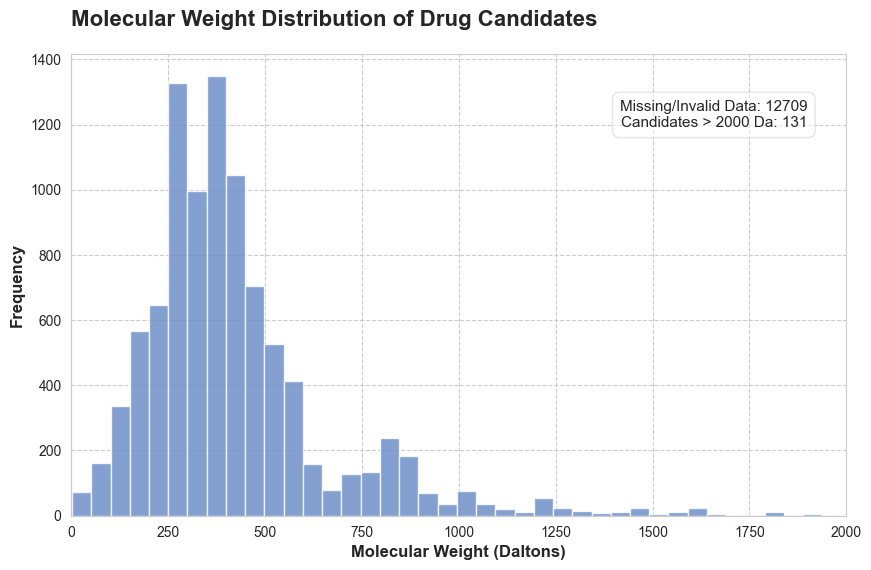

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load the data using your verified directory variables
file_path = os.path.join(PROCESSED_DIR, 'SVEF_Enriched_Final.csv')

try:
    df = pd.read_csv(file_path)
    
    # 2. Process Molecular Weight
    # Convert to numeric and count how many were missing or failed conversion
    original_count = len(df)
    df['mw_numeric'] = pd.to_numeric(df['molecular_weight'], errors='coerce')
    
    # Points that are NaN (either were empty or were non-numeric strings)
    missing_data = df[df['mw_numeric'].isna()]
    missing_count = len(missing_data)
    
    # Drop missing values for calculations
    clean_mw = df['mw_numeric'].dropna()
    
    # 3. Handle Outliers (> 2000)
    outliers = clean_mw[clean_mw > 2000]
    outlier_count = len(outliers)
    
    # Filter data to only show up to 2000 on the histogram
    plot_data = clean_mw[clean_mw <= 2000]

    # 4. Plotting
    plt.figure(figsize=(10, 6), dpi=100)
    sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--', 'grid.alpha': 0.3})
    
    # Create the histogram
    n, bins, patches = plt.hist(
        plot_data, 
        bins=40, 
        color="#6689C6", 
        edgecolor='white', 
        alpha=0.8
    )

    # 5. Add Text Annotations for missing and outlier data
    # Positioned in the top right of the plot area
    stats_text = (
        f"Missing/Invalid Data: {missing_count}\n"
        f"Candidates > 2000 Da: {outlier_count}"
    )
    plt.gca().text(
        0.95, 0.90, stats_text, 
        transform=plt.gca().transAxes, 
        fontsize=11, 
        verticalalignment='top', 
        horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.5, edgecolor='#cccccc')
    )

    # 6. Formatting
    plt.title("Molecular Weight Distribution of Drug Candidates", size=16, weight="bold", pad=20, loc='left')
    plt.xlabel("Molecular Weight (Daltons)", size=12, weight="bold")
    plt.ylabel("Frequency", size=12, weight="bold")
    plt.xlim(0, 2000) # Explicitly limit X-axis to 2000

    # Add a vertical line for the median weight (useful for discussion)
    median_mw = mw_data.median()
    plt.axvline(median_mw, color='#E85252', linestyle='--', lw=2, label=f'Median: {median_mw:.1f} Da')
    plt.legend(frameon=False, fontsize=10)
    
    sns.despine()
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # 7. Save the figure
    save_path = os.path.join(FIGURES_DIR, "molecular_weight_histogram.png")
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    
    print(f"✅ Plot saved to: {save_path}")
    print(f"Metrics: {missing_count} missing, {outlier_count} outliers excluded from view.")
    plt.show()

except NameError:
    print("Error: 'PROCESSED_DIR' or 'FIGURES_DIR' is not defined. Please run your Setup cell first.")
except FileNotFoundError:
    print(f"Error: Could not find the file at {file_path}")

Molecular weight is an attribute considered in "Lipinski's Rule of 5".  Lipinski's Rule of 5 is a traditional guideline used in drug discovery.  While note a hard rule, traditionally, molecular weights under 500 Daltons have been considered disirable for small molecule drug bioavailability.

#### Lipophilicity (LogP)

<positron-console-cell-30>:44: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<positron-console-cell-30>:45: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<positron-console-cell-30>:49: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.


✅ LogP plot saved to: C:\Users\Ownwer\Documents\BIFX\BIFX546\Final_Project\reports\figures\logp_distribution.png


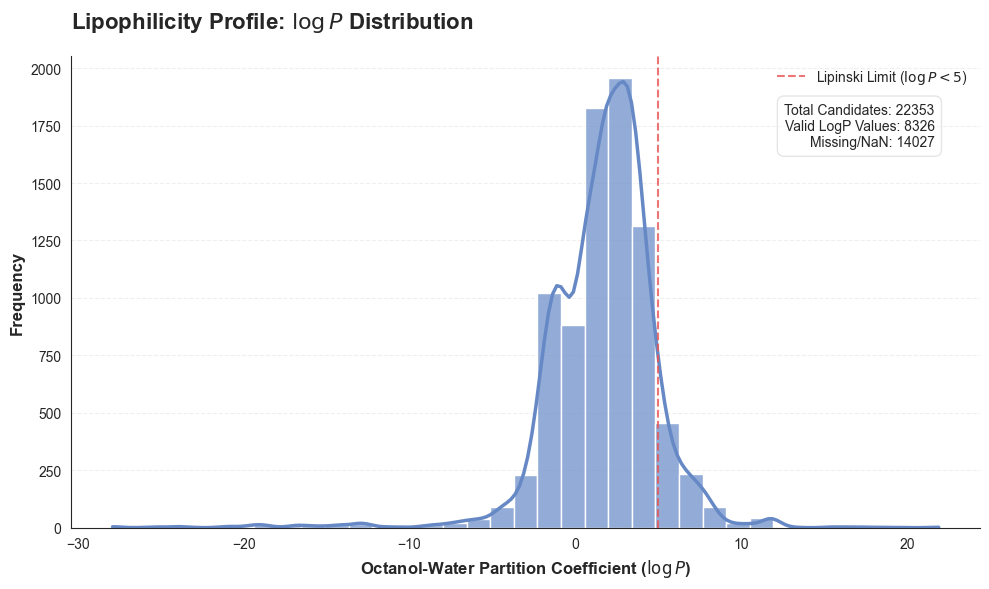

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load the Enriched Dataset
file_path = os.path.join(PROCESSED_DIR, 'SVEF_Enriched_Final.csv')

try:
    df = pd.read_csv(file_path)
    
    # 2. Process LogP Data
    # Identify the column (PubChem often uses 'xlogp' or 'logp')
    logp_col = 'xlogp' if 'xlogp' in df.columns else 'logp'
    
    if logp_col not in df.columns:
        print(f"⚠️ Column 'logp' or 'xlogp' not found. Columns: {df.columns.tolist()}")
    else:
        # Convert to numeric and identify missing/invalid entries
        df['logp_numeric'] = pd.to_numeric(df[logp_col], errors='coerce')
        
        missing_count = df['logp_numeric'].isna().sum()
        clean_logp = df['logp_numeric'].dropna()

        # 3. Plotting
        plt.figure(figsize=(10, 6), dpi=100)
        sns.set_style("white")
        
        # Create Histogram with Density Curve
        sns.histplot(clean_logp, bins=35, color="#6689C6", kde=True, 
                     edgecolor='white', alpha=0.7, line_kws={'lw': 2.5})

        # 4. Add Statistics Annotation
        stats_text = (
            f"Total Candidates: {len(df)}\n"
            f"Valid LogP Values: {len(clean_logp)}\n"
            f"Missing/NaN: {missing_count}"
        )
        plt.gca().text(0.95, 0.90, stats_text, transform=plt.gca().transAxes, 
                       fontsize=10, verticalalignment='top', horizontalalignment='right',
                       bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.5, edgecolor='#cccccc'))

        # 5. Styling
        plt.title("Lipophilicity Profile: $\log P$ Distribution", size=16, weight="bold", pad=20, loc='left')
        plt.xlabel("Octanol-Water Partition Coefficient ($\log P$)", size=12, weight="bold")
        plt.ylabel("Frequency", size=12, weight="bold")
        
        # Add a reference line for Lipinski's Rule of 5 (LogP < 5)
        plt.axvline(5, color='#E85252', linestyle='--', alpha=0.8, label="Lipinski Limit ($\log P < 5$)")
        plt.legend(frameon=False)
        
        sns.despine()
        plt.grid(axis='y', linestyle='--', alpha=0.3)

        # 6. Save the Figure
        save_path = os.path.join(FIGURES_DIR, "logp_distribution.png")
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches="tight")
        
        print(f"✅ LogP plot saved to: {save_path}")
        plt.show()

except NameError:
    print("Error: 'PROCESSED_DIR' or 'FIGURES_DIR' is not defined. Run your Setup cell first.")
except FileNotFoundError:
    print(f"Error: Could not find file at {file_path}")

Lipophilicity is another attribute of "Lipinski's Rule of 5" that has been traditionally considered for small molecule drug bio availability.  Octanol-Water Partition Coefficient's less than 5 have been traditionally considered desirable.

### Insights and Next Steps

Perhaps not surprisingly, many of the drug candidates in these trials tend to be "compliant" with Octanol-Water Partition Coefficent and Molecular Weight for Lipinski's rule of 5.  Many features of this SVEF dataset need further review and validations.  PubChem was surprisingly robust in handling various names and returning hits on SMILES, Molecular Weight, and Octanol-Water Partition Coefficient.  Enrollment data was obtained; however, parsing individual arm enrollment data vs overall trial enrollment data is trickier than expected.  The safety score concept has potential use, after additional review and rework, to be used in combination with MW and LogP for predicting better candidates for ICAN.  

Four Major tasks remain:
- Review, debug, create tests, verify data in SVEF dataset.  Improve PubChem capture for candidates.
- Create a Machine Learning concept to predict which candidates are more ideal for Drug-Target-Interaction (DTI)
- Create target Protein dataset
- Train and run ICAN model


![ICAN Flow](../Background_Documents/ICAN_Flow.png)

![AACT Schema](../docs/references/aact_schema.png)